# Compare Ablation Networks

This notebook compares the ablation-study baseline and the ablated ABI-DAGAR networks on the **same fixed validation batches** used across the ablation study.

The notebook does four things:
1. checks which ablation artifacts are currently available,
2. compares training histories,
3. evaluates each trained network on the shared validation batches,
4. summarizes how parameter recovery changes when each summary-feature block is removed.

By default the notebook evaluates all available checkpoints on the full shared validation bank. You can restrict the run in the configuration cell below if you want a quicker pass while some trainings are still ongoing.


In [1]:
from __future__ import annotations

import os
import pickle
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial import Delaunay
from scipy.stats import halfnorm

os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import bayesflow as bf  # noqa: F401 - needed when loading saved BayesFlow models
import keras

PROJECT_ROOT = Path(r"C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression")
ABLATION_ROOT = PROJECT_ROOT / "Simulation Experiments" / "Ablation_experiments"
TRAINING_ROOT = ABLATION_ROOT / "Training"
RESULTS_ROOT = ABLATION_ROOT / "Results"
COMPARISON_OUTPUT_DIR = RESULTS_ROOT / "comparison_outputs"
IMAGES_DIR = COMPARISON_OUTPUT_DIR / "Images"
TABLES_DIR = COMPARISON_OUTPUT_DIR / "Tables"

for path in (COMPARISON_OUTPUT_DIR, IMAGES_DIR, TABLES_DIR):
    path.mkdir(parents=True, exist_ok=True)

NUM_POSTERIOR_SAMPLES = 1000
SAMPLING_SEED = 123
TARGET_COVERAGE = 0.95
DISPLAY_PARAMETERS = ["beta0", "sigma2_w", "eta", "rho"]
PARAMETER_LABELS = {
    "beta0": r"$\beta_0$",
    "sigma2_w": r"$\sigma_w^2$",
    "eta": r"$\eta$",
    "rho": r"$\rho$",
}
EXPERIMENT_NAMES_TO_RUN = None
MAX_VALIDATION_BATCHES = None

# Validation-bank settings
USE_FIXED_N = False
N_FIXED = 100
N_MIN = 40
N_MAX = 120
VALIDATION_BATCH_SIZE = 50
VALIDATION_DATASET_SIZE = 4050
SHARED_VALIDATION_BATCH_SEED = 2026051202
ORDERING_MODE = "identity"
ETA_RAW_LOWER = 0.0

plt.rcParams.update({"figure.dpi": 150})
warnings.filterwarnings("ignore", category=FutureWarning)

print("Comparison output directory:")
print(COMPARISON_OUTPUT_DIR)


INFO:bayesflow:Using backend 'tensorflow'


Comparison output directory:
C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\comparison_outputs


In [2]:
FULL_SUMMARY_FEATURE_NAMES = [
    "x",
    "log_y",
    "log_e",
    "r",
    "degree",
    "r_lag_all",
    "absdiff_all",
    "r_lag_low",
    "r_lag_mid",
    "r_lag_high",
    "absdiff_low",
    "absdiff_mid",
    "absdiff_high",
    "prop_low",
    "prop_mid",
    "prop_high",
    "mean_z_rel",
    "max_z_rel",
    "local_moran",
    "local_semivar",
    "M",
    "edge_absdiff_slope",
    "edge_absdiff_gap",
    "edge_concord_gap",
    "edge_corr_all",
    "lag_corr_all",
    "lag_slope_all",
    "edge_semivar_all",
]

EXPERIMENTS = [
    {
        "name": "00_baseline",
        "label": "Baseline",
        "artifact_stem": "baseline_full_summaries",
        "notebook": TRAINING_ROOT / "00_baseline" / "train_baseline.ipynb",
        "ablated_features": [],
    },
    {
        "name": "01_ablate_core_observation_features",
        "label": "No core observation features",
        "artifact_stem": "ablate_core_observation_features",
        "notebook": TRAINING_ROOT / "01_ablate_core_observation_features" / "train_ablate_core_observation_features.ipynb",
        "ablated_features": ["x", "log_y", "log_e", "r"],
    },
    {
        "name": "02_ablate_graph_topology_features",
        "label": "No graph topology features",
        "artifact_stem": "ablate_graph_topology_features",
        "notebook": TRAINING_ROOT / "02_ablate_graph_topology_features" / "train_ablate_graph_topology_features.ipynb",
        "ablated_features": ["degree", "r_lag_all", "absdiff_all"],
    },
    {
        "name": "03_ablate_dissimilarity_features",
        "label": "No dissimilarity features",
        "artifact_stem": "ablate_dissimilarity_features",
        "notebook": TRAINING_ROOT / "03_ablate_dissimilarity_features" / "train_ablate_dissimilarity_features.ipynb",
        "ablated_features": [
            "r_lag_low",
            "r_lag_mid",
            "r_lag_high",
            "absdiff_low",
            "absdiff_mid",
            "absdiff_high",
            "prop_low",
            "prop_mid",
            "prop_high",
            "mean_z_rel",
            "max_z_rel",
        ],
    },
    {
        "name": "04_ablate_local_spatial_features",
        "label": "No local spatial features",
        "artifact_stem": "ablate_local_spatial_features",
        "notebook": TRAINING_ROOT / "04_ablate_local_spatial_features" / "train_ablate_local_spatial_features.ipynb",
        "ablated_features": ["local_moran", "local_semivar"],
    },
    {
        "name": "05_ablate_global_graph_features",
        "label": "No global graph features",
        "artifact_stem": "ablate_global_graph_features",
        "notebook": TRAINING_ROOT / "05_ablate_global_graph_features" / "train_ablate_global_graph_features.ipynb",
        "ablated_features": [
            "M",
            "edge_absdiff_slope",
            "edge_absdiff_gap",
            "edge_concord_gap",
            "edge_corr_all",
            "lag_corr_all",
            "lag_slope_all",
            "edge_semivar_all",
        ],
    },
    {
        "name": "06_core_observation_only",
        "label": "Only core observation features",
        "artifact_stem": "core_observation_only",
        "notebook": TRAINING_ROOT / "06_core_observation_only" / "train_core_observation_only.ipynb",
        "ablated_features": [
            "degree",
            "r_lag_all",
            "absdiff_all",
            "r_lag_low",
            "r_lag_mid",
            "r_lag_high",
            "absdiff_low",
            "absdiff_mid",
            "absdiff_high",
            "prop_low",
            "prop_mid",
            "prop_high",
            "mean_z_rel",
            "max_z_rel",
            "local_moran",
            "local_semivar",
            "M",
            "edge_absdiff_slope",
            "edge_absdiff_gap",
            "edge_concord_gap",
            "edge_corr_all",
            "lag_corr_all",
            "lag_slope_all",
            "edge_semivar_all",
        ],
    },
]

if EXPERIMENT_NAMES_TO_RUN is not None:
    requested = set(EXPERIMENT_NAMES_TO_RUN)
    EXPERIMENTS = [exp for exp in EXPERIMENTS if exp["name"] in requested]

for exp in EXPERIMENTS:
    exp["results_root"] = RESULTS_ROOT / exp["name"]
    exp["checkpoint"] = exp["results_root"] / "Checkpoints" / f"poisson_dagar_{exp['artifact_stem']}.keras"
    exp["history_csv"] = exp["results_root"] / f"training_history_{exp['artifact_stem']}.csv"
    exp["history_png"] = exp["results_root"] / "Images" / f"history_plot_{exp['artifact_stem']}.png"
    exp["drop_feature_indices"] = [FULL_SUMMARY_FEATURE_NAMES.index(name) for name in exp["ablated_features"]]

experiments_df = pd.DataFrame([
    {
        "experiment": exp["name"],
        "label": exp["label"],
        "n_ablated_features": len(exp["ablated_features"]),
        "ablated_features": ", ".join(exp["ablated_features"]) if exp["ablated_features"] else "none",
        "checkpoint": str(exp["checkpoint"]),
        "history_csv": str(exp["history_csv"]),
    }
    for exp in EXPERIMENTS
])

display(experiments_df)


,experiment,label,n_ablated_features,ablated_features,checkpoint,history_csv
0,00_baseline,Baseline,0,none,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
1,01_ablate_core_observation_features,No core observation features,4,"x, log_y, log_e, r",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
2,02_ablate_graph_topology_features,No graph topology features,3,"degree, r_lag_all, absdiff_all",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
3,03_ablate_dissimilarity_features,No dissimilarity features,11,"r_lag_low, r_lag_mid, r_lag_high, absdiff_low,...",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
4,04_ablate_local_spatial_features,No local spatial features,2,"local_moran, local_semivar",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
5,05_ablate_global_graph_features,No global graph features,8,"M, edge_absdiff_slope, edge_absdiff_gap, edge_...",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
6,06_core_observation_only,Only core observation features,24,"degree, r_lag_all, absdiff_all, r_lag_low, r_l...",C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...


In [3]:
SHARED_VALIDATION_BATCHES_PATH = RESULTS_ROOT / "shared_data" / "validation_batches_full_summaries_allN_n4050_maxbs50_n40_120_seed2026051202.pkl"


def _clone_batch(batch):
    return {
        key: value.copy() if isinstance(value, np.ndarray) else value
        for key, value in batch.items()
    }


def _apply_feature_ablation(obs_full, drop_feature_indices=None):
    obs_full = np.asarray(obs_full, dtype=np.float32)
    if not drop_feature_indices:
        return obs_full.copy()
    keep_mask = np.ones(obs_full.shape[-1], dtype=bool)
    keep_mask[np.asarray(drop_feature_indices, dtype=int)] = False
    return obs_full[..., keep_mask].astype(np.float32)


def _prepare_batch_for_experiment(batch_full, drop_feature_indices):
    batch = _clone_batch(batch_full)
    batch["obs"] = _apply_feature_ablation(batch["obs"], drop_feature_indices)
    return batch


def _build_conditions_from_batch(batch):
    return {
        "obs": np.asarray(batch["obs"], dtype=np.float32),
        "N": batch["N"],
    }


def _set_global_seed(seed):
    np.random.seed(seed)
    utils = getattr(keras, "utils", None)
    if utils is not None and hasattr(utils, "set_random_seed"):
        utils.set_random_seed(seed)


def _random_adjacency(N):
    points = np.random.uniform(0, 10, size=(N, 2))
    tri = Delaunay(points)
    A = np.zeros((N, N), dtype=int)
    for simplex in tri.simplices:
        for i in range(3):
            for j in range(i + 1, 3):
                n1, n2 = simplex[i], simplex[j]
                A[n1, n2] = 1
                A[n2, n1] = 1
    return A


def _dagar_factors(A, rho, ordering):
    n = A.shape[0]
    rho2 = rho ** 2
    inv_order = np.argsort(ordering)

    B = np.zeros((n, n))
    lam = np.zeros(n)

    for pos in range(n):
        i = ordering[pos]
        preds = [ordering[q] for q in range(pos) if A[i, ordering[q]] == 1]
        n_lt = len(preds)
        denom = 1.0 + max(n_lt - 1, 0) * rho2
        b_val = rho / denom if n_lt > 0 else 0.0
        for j in preds:
            B[pos, inv_order[j]] = b_val
        lam[pos] = denom / (1.0 - rho2)

    ImB = np.eye(n) - B
    return ImB, lam


def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    x_c = x - x.mean()
    y_c = y - y.mean()
    denom = np.sqrt(np.mean(x_c ** 2) * np.mean(y_c ** 2))
    if denom < 1e-8:
        return 0.0
    return float(np.mean(x_c * y_c) / denom)


def _safe_mean_1d(values):
    return float(values.mean()) if values.size > 0 else 0.0


def _masked_row_mean(values, mask):
    mask_f = mask.astype(np.float32)
    denom = mask_f.sum(axis=1)
    denom_safe = np.where(denom == 0, 1.0, denom)
    out = (values * mask_f).sum(axis=1) / denom_safe
    out[denom == 0] = 0.0
    return out.astype(np.float32)


def _repair_isolates_deterministic(A_filtered, A, Z):
    A_rep = A_filtered.copy().astype(np.float32)
    for i in range(A_rep.shape[0]):
        if A_rep[i].sum() == 0:
            neighbors = np.where(A[i] == 1)[0]
            if len(neighbors) > 0:
                j = neighbors[np.argmin(Z[i, neighbors])]
                A_rep[i, j] = 1.0
                A_rep[j, i] = 1.0
    return A_rep


def _get_ordering(A):
    n = A.shape[0]
    if ORDERING_MODE == "random":
        return np.random.permutation(n).astype(int)
    if ORDERING_MODE == "identity":
        return np.arange(n, dtype=int)
    raise ValueError(f"Unknown ORDERING_MODE: {ORDERING_MODE}")


def _observed_eta_signal_metrics(y, e, A, Z, Z_median, r_lag_all=None):
    A_bool = A == 1
    edge_i, edge_j = np.where(np.triu(A_bool, 1))

    zero_metrics = dict(
        edge_absdiff_low=0.0,
        edge_absdiff_mid=0.0,
        edge_absdiff_high=0.0,
        edge_concord_low=0.0,
        edge_concord_mid=0.0,
        edge_concord_high=0.0,
        edge_absdiff_slope=0.0,
        edge_absdiff_gap=0.0,
        edge_concord_gap=0.0,
        edge_corr_all=0.0,
        lag_corr_all=0.0,
        lag_slope_all=0.0,
        edge_semivar_all=0.0,
        local_moran_mean=0.0,
    )
    if edge_i.size == 0:
        return zero_metrics

    r = (np.log(y + 0.5) - np.log(e)).astype(np.float32)
    z_rel = (Z / Z_median).astype(np.float32)
    z_edge = z_rel[edge_i, edge_j]
    absdiff_edge = np.abs(r[edge_i] - r[edge_j]).astype(np.float32)
    sqdiff_edge = ((r[edge_i] - r[edge_j]) ** 2).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r = float(np.mean(r_centered ** 2))
    var_r_safe = max(var_r, 1e-8)
    concord_edge = (r_centered[edge_i] * r_centered[edge_j]).astype(np.float32)

    low = z_edge <= 0.75
    mid = (z_edge > 0.75) & (z_edge <= 1.25)
    high = z_edge > 1.25

    z_bar = float(z_edge.mean())
    absdiff_bar = float(absdiff_edge.mean())
    var_z = float(np.mean((z_edge - z_bar) ** 2))
    if var_z < 1e-8:
        edge_absdiff_slope = 0.0
    else:
        edge_absdiff_slope = float(np.mean((z_edge - z_bar) * (absdiff_edge - absdiff_bar)) / var_z)

    if r_lag_all is None:
        degree = A_bool.sum(axis=1).astype(np.float32)
        degree_safe = np.where(degree == 0, 1.0, degree)
        W = A / degree_safe[:, None]
        r_lag_all = (W @ r).astype(np.float32)

    r_lag_centered = (r_lag_all - r_lag_all.mean()).astype(np.float32)
    lag_slope_all = float(np.mean(r_centered * r_lag_centered) / var_r_safe)
    lag_corr_all = _safe_corr(r, r_lag_all)
    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    edge_corr_all = float(np.mean(concord_edge) / var_r_safe)
    edge_semivar_all = float(0.5 * np.mean(sqdiff_edge))

    return dict(
        edge_absdiff_low=_safe_mean_1d(absdiff_edge[low]),
        edge_absdiff_mid=_safe_mean_1d(absdiff_edge[mid]),
        edge_absdiff_high=_safe_mean_1d(absdiff_edge[high]),
        edge_concord_low=_safe_mean_1d(concord_edge[low]),
        edge_concord_mid=_safe_mean_1d(concord_edge[mid]),
        edge_concord_high=_safe_mean_1d(concord_edge[high]),
        edge_absdiff_slope=edge_absdiff_slope,
        edge_absdiff_gap=_safe_mean_1d(absdiff_edge[high]) - _safe_mean_1d(absdiff_edge[low]),
        edge_concord_gap=_safe_mean_1d(concord_edge[low]) - _safe_mean_1d(concord_edge[high]),
        edge_corr_all=edge_corr_all,
        lag_corr_all=lag_corr_all,
        lag_slope_all=lag_slope_all,
        edge_semivar_all=edge_semivar_all,
        local_moran_mean=float(local_moran.mean()),
    )


def _build_full_observed_features(x, y, e, A, Z, Z_median, M):
    A_bool = A == 1
    x = x.astype(np.float32)
    y = y.astype(np.float32)
    e = e.astype(np.float32)

    log_y = np.log1p(y).astype(np.float32)
    log_e = np.log(e).astype(np.float32)
    r = (np.log(y + 0.5) - log_e).astype(np.float32)
    r_centered = (r - r.mean()).astype(np.float32)
    var_r_safe = max(float(np.mean(r_centered ** 2)), 1e-8)

    degree = A_bool.sum(axis=1).astype(np.float32)
    degree_safe = np.where(degree == 0, 1.0, degree)

    z_rel = (Z / Z_median).astype(np.float32)
    neigh_r = np.broadcast_to(r[None, :], z_rel.shape).astype(np.float32)
    abs_r_diff = np.abs(r[:, None] - r[None, :]).astype(np.float32)

    low_mask = A_bool & (z_rel <= 0.75)
    mid_mask = A_bool & (z_rel > 0.75) & (z_rel <= 1.25)
    high_mask = A_bool & (z_rel > 1.25)

    r_lag_all = _masked_row_mean(neigh_r, A_bool)
    absdiff_all = _masked_row_mean(abs_r_diff, A_bool)
    r_lag_low = _masked_row_mean(neigh_r, low_mask)
    r_lag_mid = _masked_row_mean(neigh_r, mid_mask)
    r_lag_high = _masked_row_mean(neigh_r, high_mask)
    absdiff_low = _masked_row_mean(abs_r_diff, low_mask)
    absdiff_mid = _masked_row_mean(abs_r_diff, mid_mask)
    absdiff_high = _masked_row_mean(abs_r_diff, high_mask)
    prop_low = (low_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_mid = (mid_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_high = (high_mask.sum(axis=1) / degree_safe).astype(np.float32)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_z_rel = np.nanmean(np.where(A_bool, z_rel, np.nan), axis=1)
        max_z_rel = np.nanmax(np.where(A_bool, z_rel, np.nan), axis=1)

    mean_z_rel = np.nan_to_num(mean_z_rel, nan=0.0).astype(np.float32)
    max_z_rel = np.nan_to_num(max_z_rel, nan=0.0).astype(np.float32)

    edge_metrics = _observed_eta_signal_metrics(y=y, e=e, A=A, Z=Z, Z_median=Z_median, r_lag_all=r_lag_all)
    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    local_semivar = (((r - r_lag_all) ** 2) / var_r_safe).astype(np.float32)

    obs_full = np.stack(
        [
            x,
            log_y,
            log_e,
            r,
            degree,
            r_lag_all,
            absdiff_all,
            r_lag_low,
            r_lag_mid,
            r_lag_high,
            absdiff_low,
            absdiff_mid,
            absdiff_high,
            prop_low,
            prop_mid,
            prop_high,
            mean_z_rel,
            max_z_rel,
            local_moran,
            local_semivar,
            np.full(len(x), M, dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_slope"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_concord_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_slope_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_semivar_all"], dtype=np.float32),
        ],
        axis=-1,
    ).astype(np.float32)
    return obs_full.astype(np.float32)


def _simulate_single_full_dataset(n_value):
    beta_0 = np.random.normal(0.0, 0.5)
    sigma2_w = halfnorm.rvs(scale=0.5)
    eta_raw = np.random.uniform(ETA_RAW_LOWER, 1.0)
    rho = np.random.uniform(0.0, 1.0)

    A_sim = _random_adjacency(int(n_value)).astype(np.float32)
    x = np.random.normal(0.0, 1.0, size=n_value).astype(np.float32)
    Z = np.abs(x[:, None] - x[None, :]).astype(np.float32)

    Z_edges = Z[A_sim == 1]
    Z_median = 1.0 if Z_edges.size == 0 else float(np.median(Z_edges) + 1e-8)
    M = float(np.log(2.0) / Z_median)
    eta = float(eta_raw * M)

    A_filtered = A_sim * ((Z * eta) <= np.log(2.0)).astype(np.float32)
    A_filtered = _repair_isolates_deterministic(A_filtered, A_sim, Z)

    ordering = _get_ordering(A_sim)
    ImB, dagar_lam = _dagar_factors(A_filtered, rho, ordering)
    z = np.random.normal(size=n_value).astype(np.float32)
    rhs = np.sqrt(sigma2_w) * z / np.sqrt(dagar_lam)
    w = np.linalg.solve(ImB, rhs).astype(np.float32)
    w = w - np.mean(w)

    log_e = np.random.uniform(np.log(2.0), np.log(30000.0), size=n_value)
    e = np.exp(log_e).astype(np.float32)
    poisson_lam = np.clip(np.exp(np.log(e) + beta_0 + w), 1e-2, 1e6)
    y = np.random.poisson(poisson_lam).astype(np.float32)

    obs = _build_full_observed_features(x=x, y=y, e=e, A=A_sim, Z=Z, Z_median=Z_median, M=M)
    return {
        "N": int(n_value),
        "beta": np.array([beta_0], dtype=np.float32),
        "sigma2_w": np.array([sigma2_w], dtype=np.float32),
        "eta_raw": np.array([eta_raw], dtype=np.float32),
        "rho": np.array([rho], dtype=np.float32),
        "obs": obs.astype(np.float32),
        "M": np.array([M], dtype=np.float32),
        "A": A_sim.astype(np.float32),
        "A_filtered": A_filtered.astype(np.float32),
    }


def _build_n_schedule(dataset_size, seed):
    if USE_FIXED_N:
        return np.repeat(int(N_FIXED), dataset_size).astype(int)
    rng = np.random.default_rng(seed)
    all_n = np.arange(N_MIN, N_MAX + 1, dtype=int)
    repeats, remainder = divmod(dataset_size, all_n.size)
    schedule = np.tile(all_n, repeats)
    if remainder:
        extra = all_n.copy()
        rng.shuffle(extra)
        schedule = np.concatenate([schedule, extra[:remainder]])
    rng.shuffle(schedule)
    return schedule.astype(int)


def _stack_dataset_group(datasets):
    first = datasets[0]
    batch = {}
    for key, value in first.items():
        if isinstance(value, np.ndarray):
            batch[key] = np.stack([dataset[key] for dataset in datasets], axis=0)
        else:
            batch[key] = value
    return batch


def _group_datasets_into_batches(datasets, max_batch_size):
    grouped = {}
    for dataset in datasets:
        grouped.setdefault(int(dataset["N"]), []).append(dataset)
    batches = []
    for n_value in sorted(grouped):
        members = grouped[n_value]
        for start in range(0, len(members), max_batch_size):
            batches.append(_stack_dataset_group(members[start:start + max_batch_size]))
    return batches


def _load_or_create_validation_batches(path, dataset_size, seed, max_batch_size):
    if path.exists():
        with open(path, "rb") as f:
            batches = pickle.load(f)
        print(f"Loaded shared validation bank: {path}")
        return batches

    path.parent.mkdir(parents=True, exist_ok=True)
    schedule = _build_n_schedule(dataset_size, seed)
    old_state = np.random.get_state()
    np.random.seed(seed)
    try:
        datasets = [_simulate_single_full_dataset(int(n_value)) for n_value in schedule]
    finally:
        np.random.set_state(old_state)

    batches = _group_datasets_into_batches(datasets, max_batch_size=max_batch_size)
    with open(path, "wb") as f:
        pickle.dump(batches, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Created shared validation bank: {path}")
    return batches


validation_batches_full = _load_or_create_validation_batches(
    SHARED_VALIDATION_BATCHES_PATH,
    VALIDATION_DATASET_SIZE,
    SHARED_VALIDATION_BATCH_SEED,
    VALIDATION_BATCH_SIZE,
)

if MAX_VALIDATION_BATCHES is not None:
    validation_batches_full = validation_batches_full[:MAX_VALIDATION_BATCHES]

batch_sizes = [int(np.asarray(batch["obs"]).shape[0]) for batch in validation_batches_full]
distinct_n_values = sorted({int(batch["N"]) for batch in validation_batches_full})
full_feature_dim = int(np.asarray(validation_batches_full[0]["obs"]).shape[-1])
total_validation_datasets = int(sum(batch_sizes))

status_rows = []
for exp in EXPERIMENTS:
    status_rows.append(
        {
            "experiment": exp["name"],
            "label": exp["label"],
            "checkpoint_exists": exp["checkpoint"].exists(),
            "history_exists": exp["history_csv"].exists(),
            "n_ablated_features": len(exp["ablated_features"]),
        }
    )
status_df = pd.DataFrame(status_rows)

display(status_df)
print(f"Validation batches loaded    : {len(validation_batches_full)}")
print(f"Total validation datasets    : {total_validation_datasets}")
print(f"Distinct N values in validation: {len(distinct_n_values)}")
print(f"First 10 N values            : {distinct_n_values[:10]}")
print(f"Last 10 N values             : {distinct_n_values[-10:]}")
print(f"Batch size range             : [{min(batch_sizes)}, {max(batch_sizes)}]")
print(f"Full summary feature dim     : {full_feature_dim}")


Loaded shared validation bank: C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\shared_data\validation_batches_full_summaries_allN_n4050_maxbs50_n40_120_seed2026051202.pkl


,experiment,label,checkpoint_exists,history_exists,n_ablated_features
0,00_baseline,Baseline,True,True,0
1,01_ablate_core_observation_features,No core observation features,True,True,4
2,02_ablate_graph_topology_features,No graph topology features,True,True,3
3,03_ablate_dissimilarity_features,No dissimilarity features,True,True,11
4,04_ablate_local_spatial_features,No local spatial features,True,True,2
5,05_ablate_global_graph_features,No global graph features,True,True,8
6,06_core_observation_only,Only core observation features,True,True,24


Validation batches loaded    : 81
Total validation datasets    : 4050
Distinct N values in validation: 81
First 10 N values            : [40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
Last 10 N values             : [111, 112, 113, 114, 115, 116, 117, 118, 119, 120]
Batch size range             : [50, 50]
Full summary feature dim     : 28


,experiment,label,epochs_completed,final_loss,min_loss,final_val_loss,min_val_loss
5,05_ablate_global_graph_features,No global graph features,40,0.227514,0.227514,0.569993,0.556518
3,03_ablate_dissimilarity_features,No dissimilarity features,40,0.278968,0.271270,0.609732,0.604779
2,02_ablate_graph_topology_features,No graph topology features,40,0.256429,0.256429,0.629044,0.619211
4,04_ablate_local_spatial_features,No local spatial features,40,0.240249,0.240249,0.627985,0.624844
0,00_baseline,Baseline,40,0.257724,0.257724,0.669894,0.644690
1,01_ablate_core_observation_features,No core observation features,40,0.561940,0.561940,1.024172,1.016825
6,06_core_observation_only,Only core observation features,40,1.000912,1.000912,1.039530,1.039530


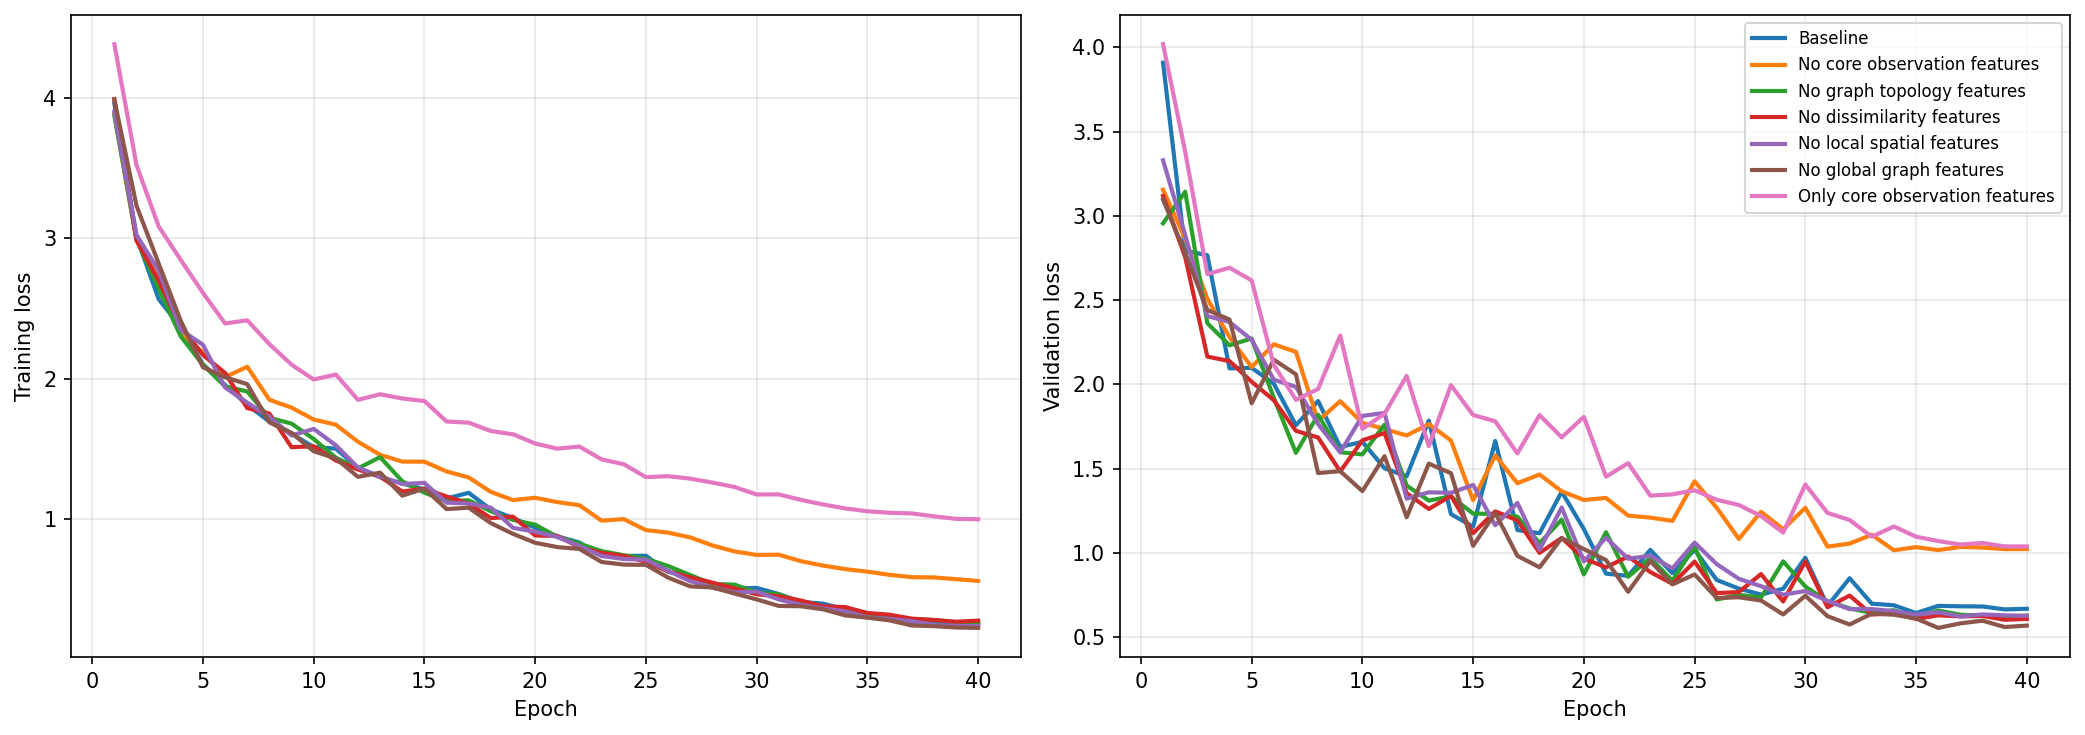

In [4]:
history_frames = []
history_summary_rows = []

for exp in EXPERIMENTS:
    if not exp["history_csv"].exists():
        continue

    hist = pd.read_csv(exp["history_csv"]).copy()
    hist["epoch"] = np.arange(1, len(hist) + 1, dtype=int)
    hist["experiment"] = exp["name"]
    hist["label"] = exp["label"]
    history_frames.append(hist)

    history_summary_rows.append(
        {
            "experiment": exp["name"],
            "label": exp["label"],
            "epochs_completed": int(len(hist)),
            "final_loss": float(hist["loss"].iloc[-1]),
            "min_loss": float(hist["loss"].min()),
            "final_val_loss": float(hist["val_loss"].iloc[-1]) if "val_loss" in hist else np.nan,
            "min_val_loss": float(hist["val_loss"].min()) if "val_loss" in hist else np.nan,
        }
    )

history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
history_summary_df = pd.DataFrame(history_summary_rows)

if not history_df.empty:
    history_df.to_csv(TABLES_DIR / "training_history_long.csv", index=False)
    history_summary_df.to_csv(TABLES_DIR / "training_history_summary.csv", index=False)
    display(history_summary_df.sort_values("min_val_loss", na_position="last"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for label, grp in history_df.groupby("label", sort=False):
        axes[0].plot(grp["epoch"], grp["loss"], label=label, linewidth=2)
        if "val_loss" in grp:
            axes[1].plot(grp["epoch"], grp["val_loss"], label=label, linewidth=2)

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Training loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation loss")
    axes[0].grid(alpha=0.3)
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "ablation_training_histories.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No training histories found yet.")


In [5]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

parameter_rows = []
runtime_rows = []
boundary_dataset_rows = []
boundary_summary_rows = []
available_experiments = [exp for exp in EXPERIMENTS if exp["checkpoint"].exists()]

if not available_experiments:
    print("No trained ablation checkpoints found yet.")
else:
    print(f"Evaluating {len(available_experiments)} experiment(s) with {NUM_POSTERIOR_SAMPLES} posterior draws per dataset...")

boundary_threshold = float(np.log(2.0))

for exp in available_experiments:
    print(f"\n[{exp['name']}] {exp['label']}")
    keras.backend.clear_session()
    _set_global_seed(SAMPLING_SEED)
    model = keras.saving.load_model(str(exp["checkpoint"]))

    experiment_start = time.perf_counter()
    dataset_offset = 0
    experiment_boundary_dataset_rows = []
    pooled_true_edges = []
    pooled_prob_edges = []

    for batch_index, batch_full in enumerate(validation_batches_full):
        batch = _prepare_batch_for_experiment(batch_full, exp["drop_feature_indices"])
        conditions = _build_conditions_from_batch(batch)

        batch_start = time.perf_counter()
        post_draws = model.sample(conditions=conditions, num_samples=NUM_POSTERIOR_SAMPLES)
        batch_elapsed = time.perf_counter() - batch_start

        beta_draws = np.asarray(post_draws["beta"], dtype=np.float32)[:, :, 0]
        sigma2_w_draws = np.asarray(post_draws["sigma2_w"], dtype=np.float32)[:, :, 0]
        eta_raw_draws = np.asarray(post_draws["eta_raw"], dtype=np.float32)[:, :, 0]
        rho_draws = np.asarray(post_draws["rho"], dtype=np.float32)[:, :, 0]

        m_vals = np.asarray(batch["M"], dtype=np.float32)[:, 0]
        eta_draws = eta_raw_draws * m_vals[:, None]

        truth_map = {
            "beta0": np.asarray(batch["beta"], dtype=np.float32)[:, 0],
            "sigma2_w": np.asarray(batch["sigma2_w"], dtype=np.float32)[:, 0],
            "eta_raw": np.asarray(batch["eta_raw"], dtype=np.float32)[:, 0],
            "eta": np.asarray(batch["eta_raw"], dtype=np.float32)[:, 0] * m_vals,
            "rho": np.asarray(batch["rho"], dtype=np.float32)[:, 0],
        }
        draw_map = {
            "beta0": beta_draws,
            "sigma2_w": sigma2_w_draws,
            "eta_raw": eta_raw_draws,
            "eta": eta_draws,
            "rho": rho_draws,
        }

        if isinstance(batch["N"], np.ndarray):
            n_values = np.asarray(batch["N"]).reshape(-1)
        else:
            n_values = np.repeat(int(batch["N"]), beta_draws.shape[0])

        batch_dataset_count = beta_draws.shape[0]
        for local_index in range(batch_dataset_count):
            dataset_index = dataset_offset + local_index
            for parameter, draws_by_dataset in draw_map.items():
                draws = np.asarray(draws_by_dataset[local_index], dtype=np.float32)
                truth = float(truth_map[parameter][local_index])
                q025, q50, q975 = np.quantile(draws, [0.025, 0.5, 0.975])
                mean_val = float(np.mean(draws))

                parameter_rows.append(
                    {
                        "experiment": exp["name"],
                        "label": exp["label"],
                        "dataset_index": int(dataset_index),
                        "batch_index": int(batch_index),
                        "within_batch_index": int(local_index),
                        "N": int(n_values[local_index]),
                        "parameter": parameter,
                        "truth": truth,
                        "posterior_mean": mean_val,
                        "posterior_sd": float(np.std(draws, ddof=1)),
                        "posterior_median": float(q50),
                        "lower_95": float(q025),
                        "upper_95": float(q975),
                        "bias_mean": float(mean_val - truth),
                        "abs_error_mean": float(abs(mean_val - truth)),
                        "covered_95": int(q025 <= truth <= q975),
                    }
                )

            A = np.asarray(batch_full["A"][local_index], dtype=np.float32)
            A_filtered = np.asarray(batch_full["A_filtered"][local_index], dtype=np.float32)
            x_vals = np.asarray(batch_full["obs"][local_index, :, 0], dtype=np.float32)
            z_mat = np.abs(x_vals[:, None] - x_vals[None, :]).astype(np.float32)
            i_edges, j_edges = np.where(np.triu(A > 0.5, 1))
            edge_count = int(i_edges.size)

            if edge_count > 0:
                z_edges = z_mat[i_edges, j_edges]
                true_boundary = ((A[i_edges, j_edges] > 0.5) & (A_filtered[i_edges, j_edges] < 0.5)).astype(np.int32)
                eta_dataset_draws = np.asarray(eta_draws[local_index], dtype=np.float32)
                boundary_draws = (eta_dataset_draws[:, None] * z_edges[None, :] > boundary_threshold)
                p_boundary = boundary_draws.mean(axis=0).astype(np.float32)
                unique_labels = np.unique(true_boundary)

                auroc = float(roc_auc_score(true_boundary, p_boundary)) if unique_labels.size > 1 else np.nan
                average_precision = float(average_precision_score(true_boundary, p_boundary)) if unique_labels.size > 1 else np.nan
                brier = float(brier_score_loss(true_boundary, p_boundary))

                mpm_selected = (p_boundary > 0.5).astype(np.int32)
                tp = int(np.sum((mpm_selected == 1) & (true_boundary == 1)))
                tn = int(np.sum((mpm_selected == 0) & (true_boundary == 0)))
                fp = int(np.sum((mpm_selected == 1) & (true_boundary == 0)))
                fn = int(np.sum((mpm_selected == 0) & (true_boundary == 1)))
                mpm_sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
                mpm_specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan

                boundary_count_draws = boundary_draws.sum(axis=1).astype(np.int32)
                count_lower, count_upper = np.quantile(boundary_count_draws, [0.025, 0.975])
                true_boundary_count = int(true_boundary.sum())
                count_ppp = float(np.mean(boundary_count_draws <= true_boundary_count))
                estimated_boundary_count_mean = float(boundary_count_draws.mean())
                estimated_boundary_count_sd = float(boundary_count_draws.std(ddof=1))
                mpm_selected_boundary_count = int(mpm_selected.sum())

                boundary_row = {
                    "experiment": exp["name"],
                    "label": exp["label"],
                    "dataset_index": int(dataset_index),
                    "batch_index": int(batch_index),
                    "within_batch_index": int(local_index),
                    "N": int(n_values[local_index]),
                    "edge_count": edge_count,
                    "true_boundary_count": true_boundary_count,
                    "estimated_boundary_count_mean": estimated_boundary_count_mean,
                    "estimated_boundary_count_sd": estimated_boundary_count_sd,
                    "boundary_count_covered_95": int(count_lower <= true_boundary_count <= count_upper),
                    "boundary_count_ppp": count_ppp,
                    "mpm_selected_boundary_count": mpm_selected_boundary_count,
                    "auroc": auroc,
                    "average_precision": average_precision,
                    "brier": brier,
                    "mpm_sensitivity": mpm_sensitivity,
                    "mpm_specificity": mpm_specificity,
                }
                boundary_dataset_rows.append(boundary_row)
                experiment_boundary_dataset_rows.append(boundary_row)
                pooled_true_edges.append(true_boundary.astype(np.int8))
                pooled_prob_edges.append(p_boundary.astype(np.float32))
            else:
                boundary_row = {
                    "experiment": exp["name"],
                    "label": exp["label"],
                    "dataset_index": int(dataset_index),
                    "batch_index": int(batch_index),
                    "within_batch_index": int(local_index),
                    "N": int(n_values[local_index]),
                    "edge_count": 0,
                    "true_boundary_count": 0,
                    "estimated_boundary_count_mean": np.nan,
                    "estimated_boundary_count_sd": np.nan,
                    "boundary_count_covered_95": np.nan,
                    "boundary_count_ppp": np.nan,
                    "mpm_selected_boundary_count": np.nan,
                    "auroc": np.nan,
                    "average_precision": np.nan,
                    "brier": np.nan,
                    "mpm_sensitivity": np.nan,
                    "mpm_specificity": np.nan,
                }
                boundary_dataset_rows.append(boundary_row)
                experiment_boundary_dataset_rows.append(boundary_row)

        runtime_rows.append(
            {
                "experiment": exp["name"],
                "label": exp["label"],
                "batch_index": int(batch_index),
                "N": int(batch["N"]) if not isinstance(batch["N"], np.ndarray) else int(np.asarray(batch["N"]).reshape(-1)[0]),
                "elapsed_sec": float(batch_elapsed),
                "datasets_in_batch": int(batch_dataset_count),
                "num_samples_requested": int(NUM_POSTERIOR_SAMPLES),
                "seconds_per_dataset": float(batch_elapsed / batch_dataset_count),
                "seconds_per_1000_draws_per_dataset": float(1000.0 * batch_elapsed / (batch_dataset_count * NUM_POSTERIOR_SAMPLES)),
            }
        )

        dataset_offset += batch_dataset_count
        print(f"  batch {batch_index + 1:03d}/{len(validation_batches_full)} | N={int(batch['N'])} | n_datasets={batch_dataset_count}: {batch_elapsed:0.2f} sec")

    total_elapsed = time.perf_counter() - experiment_start
    print(f"  total validation runtime: {total_elapsed:0.2f} sec")

    exp_boundary_df = pd.DataFrame(experiment_boundary_dataset_rows)
    if pooled_true_edges:
        pooled_true = np.concatenate(pooled_true_edges)
        pooled_prob = np.concatenate(pooled_prob_edges)
        pooled_unique = np.unique(pooled_true)
        pooled_auroc = float(roc_auc_score(pooled_true, pooled_prob)) if pooled_unique.size > 1 else np.nan
        pooled_average_precision = float(average_precision_score(pooled_true, pooled_prob)) if pooled_unique.size > 1 else np.nan
        pooled_brier = float(brier_score_loss(pooled_true, pooled_prob))
    else:
        pooled_auroc = np.nan
        pooled_average_precision = np.nan
        pooled_brier = np.nan

    boundary_summary_rows.append(
        {
            "experiment": exp["name"],
            "label": exp["label"],
            "pooled_auroc": pooled_auroc,
            "pooled_average_precision": pooled_average_precision,
            "pooled_brier": pooled_brier,
            "mean_dataset_auroc": float(exp_boundary_df["auroc"].mean()),
            "mean_dataset_average_precision": float(exp_boundary_df["average_precision"].mean()),
            "mean_dataset_brier": float(exp_boundary_df["brier"].mean()),
            "mpm_mean_sensitivity": float(exp_boundary_df["mpm_sensitivity"].mean()),
            "mpm_mean_specificity": float(exp_boundary_df["mpm_specificity"].mean()),
            "boundary_count_coverage_95": float(exp_boundary_df["boundary_count_covered_95"].mean()),
            "mean_true_boundary_count": float(exp_boundary_df["true_boundary_count"].mean()),
            "mean_estimated_boundary_count": float(exp_boundary_df["estimated_boundary_count_mean"].mean()),
            "mean_mpm_selected_boundary_count": float(exp_boundary_df["mpm_selected_boundary_count"].mean()),
        }
    )

    del model
    keras.backend.clear_session()

parameter_df = pd.DataFrame(parameter_rows)
runtime_df = pd.DataFrame(runtime_rows)
boundary_dataset_df = pd.DataFrame(boundary_dataset_rows)
boundary_summary_df = pd.DataFrame(boundary_summary_rows)

if not parameter_df.empty:
    parameter_df.to_csv(TABLES_DIR / "parameter_by_dataset.csv", index=False)
    runtime_df.to_csv(TABLES_DIR / "runtime_by_batch.csv", index=False)
    if not boundary_dataset_df.empty:
        boundary_dataset_df.to_csv(TABLES_DIR / "boundary_metric_by_dataset.csv", index=False)
        boundary_summary_df.to_csv(TABLES_DIR / "boundary_metric_summary.csv", index=False)
    display(parameter_df.head())
else:
    print("Evaluation table is empty because no checkpoints were available.")


Evaluating 7 experiment(s) with 1000 posterior draws per dataset...

[00_baseline] Baseline


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

  batch 001/81 | N=40 | n_datasets=50: 1.67 sec


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

  batch 002/81 | N=41 | n_datasets=50: 1.60 sec


...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

  batch 080/81 | N=119 | n_datasets=50: 1.65 sec


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

  batch 081/81 | N=120 | n_datasets=50: 1.67 sec
  total validation runtime: 150.48 sec


,experiment,label,dataset_index,batch_index,within_batch_index,N,parameter,truth,posterior_mean,posterior_sd,posterior_median,lower_95,upper_95,bias_mean,abs_error_mean,covered_95
0,00_baseline,Baseline,0,0,0,40,beta0,-0.826107,-0.792720,0.039686,-0.791026,-0.855541,-0.729669,0.033387,0.033387,1
1,00_baseline,Baseline,0,0,0,40,sigma2_w,0.506007,0.381867,0.118946,0.348569,0.232215,0.689167,-0.124141,0.124141,1
2,00_baseline,Baseline,0,0,0,40,eta_raw,0.249225,0.390399,0.280758,0.343469,0.015730,0.950828,0.141173,0.141173,1
3,00_baseline,Baseline,0,0,0,40,eta,0.171896,0.269266,0.193645,0.236898,0.010849,0.655807,0.097370,0.097370,1
4,00_baseline,Baseline,0,0,0,40,rho,0.448375,0.201052,0.140839,0.173022,0.015037,0.563036,-0.247323,0.247323,1


In [9]:
if parameter_df.empty:
    raise RuntimeError("No ablation checkpoints were available for evaluation. Train at least one network and rerun this notebook.")

summary_df = (
    parameter_df
    .groupby(["experiment", "label", "parameter"], as_index=False)
    .agg(
        mean_bias=("bias_mean", "mean"),
        mean_abs_error=("abs_error_mean", "mean"),
        rmse=("bias_mean", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        mean_coverage_95=("covered_95", "mean"),
    )
)

spearman_rows = []
for (experiment, label, parameter), grp in parameter_df.groupby(["experiment", "label", "parameter"]):
    spearman_rows.append(
        {
            "experiment": experiment,
            "label": label,
            "parameter": parameter,
            "spearman_r": float(grp["posterior_mean"].corr(grp["truth"], method="spearman")),
        }
    )
spearman_df = pd.DataFrame(spearman_rows)
summary_df = summary_df.merge(spearman_df, on=["experiment", "label", "parameter"], how="left")
summary_df = summary_df.sort_values(["parameter", "label"]).reset_index(drop=True)

runtime_summary_df = (
    runtime_df
    .groupby(["experiment", "label"], as_index=False)
    .agg(
        total_runtime_sec=("elapsed_sec", "sum"),
        mean_seconds_per_dataset=("seconds_per_dataset", "mean"),
        mean_seconds_per_1000_draws_per_dataset=("seconds_per_1000_draws_per_dataset", "mean"),
        num_batches=("batch_index", "count"),
    )
)

summary_display_df = summary_df.loc[summary_df["parameter"].isin(DISPLAY_PARAMETERS)].copy()
summary_display_df["parameter"] = pd.Categorical(summary_display_df["parameter"], categories=DISPLAY_PARAMETERS, ordered=True)
summary_display_df = summary_display_df.sort_values(["label", "parameter"]).reset_index(drop=True)

baseline_display = summary_display_df.loc[
    summary_display_df["experiment"] == "00_baseline",
    ["parameter", "mean_abs_error", "rmse", "mean_coverage_95", "spearman_r"],
].rename(
    columns={
        "mean_abs_error": "baseline_mean_abs_error",
        "rmse": "baseline_rmse",
        "mean_coverage_95": "baseline_mean_coverage_95",
        "spearman_r": "baseline_spearman_r",
    }
)

comparison_df = summary_display_df.merge(baseline_display, on="parameter", how="left")
comparison_df["delta_mean_abs_error_vs_baseline"] = comparison_df["mean_abs_error"] - comparison_df["baseline_mean_abs_error"]
comparison_df["delta_rmse_vs_baseline"] = comparison_df["rmse"] - comparison_df["baseline_rmse"]
comparison_df["delta_coverage_vs_baseline"] = comparison_df["mean_coverage_95"] - comparison_df["baseline_mean_coverage_95"]
comparison_df["delta_spearman_vs_baseline"] = comparison_df["spearman_r"] - comparison_df["baseline_spearman_r"]

overall_df = (
    summary_display_df
    .groupby(["experiment", "label"], as_index=False)
    .agg(
        mean_abs_error_avg=("mean_abs_error", "mean"),
        rmse_avg=("rmse", "mean"),
        mean_coverage_95_avg=("mean_coverage_95", "mean"),
        mean_abs_coverage_gap=("mean_coverage_95", lambda s: float(np.mean(np.abs(s - TARGET_COVERAGE)))),
        mean_spearman_r=("spearman_r", "mean"),
    )
    .merge(runtime_summary_df, on=["experiment", "label"], how="left")
)

if not history_summary_df.empty:
    overall_df = overall_df.merge(
        history_summary_df[["experiment", "label", "final_loss", "min_loss", "final_val_loss", "min_val_loss"]],
        on=["experiment", "label"],
        how="left",
    )

overall_df = overall_df.sort_values("mean_abs_error_avg").reset_index(drop=True)

summary_df.to_csv(TABLES_DIR / "parameter_recovery_summary_all_parameters.csv", index=False)
summary_display_df.to_csv(TABLES_DIR / "parameter_recovery_summary_display_parameters.csv", index=False)
comparison_df.to_csv(TABLES_DIR / "parameter_recovery_vs_baseline.csv", index=False)
runtime_summary_df.to_csv(TABLES_DIR / "runtime_summary.csv", index=False)
overall_df.to_csv(TABLES_DIR / "overall_ablation_summary.csv", index=False)

BOUNDARY_METRIC_COLUMNS = [
    "pooled_auroc",
    "pooled_average_precision",
    "pooled_brier",
    "mpm_mean_sensitivity",
    "mpm_mean_specificity",
    "boundary_count_coverage_95",
]

if not boundary_summary_df.empty:
    boundary_comparison_df = boundary_summary_df.copy()
    baseline_boundary = boundary_summary_df.loc[
        boundary_summary_df["experiment"] == "00_baseline",
        ["pooled_auroc", "pooled_average_precision", "pooled_brier", "mpm_mean_sensitivity", "mpm_mean_specificity", "boundary_count_coverage_95"],
    ]

    if not baseline_boundary.empty:
        baseline_values = baseline_boundary.iloc[0].to_dict()
        boundary_comparison_df["baseline_pooled_auroc"] = float(baseline_values["pooled_auroc"])
        boundary_comparison_df["baseline_pooled_average_precision"] = float(baseline_values["pooled_average_precision"])
        boundary_comparison_df["baseline_pooled_brier"] = float(baseline_values["pooled_brier"])
        boundary_comparison_df["baseline_mpm_mean_sensitivity"] = float(baseline_values["mpm_mean_sensitivity"])
        boundary_comparison_df["baseline_mpm_mean_specificity"] = float(baseline_values["mpm_mean_specificity"])
        boundary_comparison_df["baseline_boundary_count_coverage_95"] = float(baseline_values["boundary_count_coverage_95"])
    else:
        boundary_comparison_df["baseline_pooled_auroc"] = np.nan
        boundary_comparison_df["baseline_pooled_average_precision"] = np.nan
        boundary_comparison_df["baseline_pooled_brier"] = np.nan
        boundary_comparison_df["baseline_mpm_mean_sensitivity"] = np.nan
        boundary_comparison_df["baseline_mpm_mean_specificity"] = np.nan
        boundary_comparison_df["baseline_boundary_count_coverage_95"] = np.nan

    boundary_comparison_df["delta_pooled_auroc_vs_baseline"] = boundary_comparison_df["pooled_auroc"] - boundary_comparison_df["baseline_pooled_auroc"]
    boundary_comparison_df["delta_pooled_average_precision_vs_baseline"] = boundary_comparison_df["pooled_average_precision"] - boundary_comparison_df["baseline_pooled_average_precision"]
    boundary_comparison_df["delta_pooled_brier_vs_baseline"] = boundary_comparison_df["pooled_brier"] - boundary_comparison_df["baseline_pooled_brier"]
    boundary_comparison_df["delta_mpm_mean_sensitivity_vs_baseline"] = boundary_comparison_df["mpm_mean_sensitivity"] - boundary_comparison_df["baseline_mpm_mean_sensitivity"]
    boundary_comparison_df["delta_mpm_mean_specificity_vs_baseline"] = boundary_comparison_df["mpm_mean_specificity"] - boundary_comparison_df["baseline_mpm_mean_specificity"]
    boundary_comparison_df["delta_boundary_count_coverage_95_vs_baseline"] = boundary_comparison_df["boundary_count_coverage_95"] - boundary_comparison_df["baseline_boundary_count_coverage_95"]

    boundary_summary_df.to_csv(TABLES_DIR / "boundary_metric_summary.csv", index=False)
    boundary_comparison_df.to_csv(TABLES_DIR / "boundary_metric_vs_baseline.csv", index=False)
else:
    boundary_comparison_df = pd.DataFrame()

print("Display-parameter recovery summary:")
display(summary_display_df)
print("Overall experiment summary:")
display(overall_df)
if not boundary_summary_df.empty:
    print("Boundary-detection summary:")
    display(boundary_summary_df)


Display-parameter recovery summary:


,experiment,label,parameter,mean_bias,mean_abs_error,rmse,mean_coverage_95,spearman_r
0,00_baseline,Baseline,beta0,0.000802,0.022267,0.029923,0.933827,0.998634
1,00_baseline,Baseline,sigma2_w,-0.005279,0.132329,0.189808,0.938272,0.793997
2,00_baseline,Baseline,eta,0.012838,0.140333,0.174892,0.947654,0.569154
3,00_baseline,Baseline,rho,0.000311,0.138715,0.177710,0.942716,0.789486
4,01_ablate_core_observation_features,No core observation features,beta0,-0.000595,0.027143,0.036096,0.935309,0.997702
5,01_ablate_core_observation_features,No core observation features,sigma2_w,-0.007325,0.132726,0.189976,0.937531,0.792255
6,01_ablate_core_observation_features,No core observation features,eta,0.014491,0.142012,0.177216,0.946914,0.553354
7,01_ablate_core_observation_features,No core observation features,rho,-0.001861,0.144765,0.185433,0.941481,0.767778
8,03_ablate_dissimilarity_features,No dissimilarity features,beta0,-0.001218,0.021047,0.028350,0.949136,0.998741
9,03_ablate_dissimilarity_features,No dissimilarity features,sigma2_w,-0.005590,0.131816,0.189372,0.942469,0.795595


Overall experiment summary:


,experiment,label,mean_abs_error_avg,rmse_avg,mean_coverage_95_avg,mean_abs_coverage_gap,mean_spearman_r,total_runtime_sec,mean_seconds_per_dataset,mean_seconds_per_1000_draws_per_dataset,num_batches,final_loss,min_loss,final_val_loss,min_val_loss
0,05_ablate_global_graph_features,No global graph features,0.108131,0.142550,0.940802,0.009198,0.785125,135.991087,0.033578,0.033578,81,0.227514,0.227514,0.569993,0.556518
1,00_baseline,Baseline,0.108411,0.143083,0.940617,0.009383,0.787818,135.489801,0.033454,0.033454,81,0.257724,0.257724,0.669894,0.644690
2,04_ablate_local_spatial_features,No local spatial features,0.108710,0.143709,0.940247,0.009753,0.784280,137.480807,0.033946,0.033946,81,0.240249,0.240249,0.627985,0.624844
3,03_ablate_dissimilarity_features,No dissimilarity features,0.108757,0.143482,0.945617,0.004383,0.784149,139.791919,0.034517,0.034517,81,0.278968,0.271270,0.609732,0.604779
4,02_ablate_graph_topology_features,No graph topology features,0.108881,0.143951,0.937901,0.012099,0.784566,148.652759,0.036704,0.036704,81,0.256429,0.256429,0.629044,0.619211
5,01_ablate_core_observation_features,No core observation features,0.111662,0.147180,0.940309,0.009691,0.777772,141.332468,0.034897,0.034897,81,0.561940,0.561940,1.024172,1.016825
6,06_core_observation_only,Only core observation features,0.139401,0.172085,0.955062,0.006420,0.600921,135.772845,0.033524,0.033524,81,1.000912,1.000912,1.039530,1.039530


Boundary-detection summary:


,experiment,label,pooled_auroc,pooled_average_precision,pooled_brier,mean_dataset_auroc,mean_dataset_average_precision,mean_dataset_brier,mpm_mean_sensitivity,mpm_mean_specificity,boundary_count_coverage_95,mean_true_boundary_count,mean_estimated_boundary_count,mean_mpm_selected_boundary_count
0,00_baseline,Baseline,0.944083,0.772331,0.073830,0.995553,0.988245,0.075244,0.730387,0.933738,0.993580,40.43679,44.567982,41.952593
1,01_ablate_core_observation_features,No core observation features,0.942589,0.765513,0.074940,0.995562,0.988534,0.076376,0.735446,0.931352,0.993333,40.43679,44.800567,42.528148
2,02_ablate_graph_topology_features,No graph topology features,0.943404,0.768611,0.074344,0.995546,0.988302,0.075884,0.739710,0.932522,0.991605,40.43679,44.681631,42.229136
3,03_ablate_dissimilarity_features,No dissimilarity features,0.942625,0.764352,0.074934,0.995553,0.988524,0.076397,0.735149,0.932012,0.993333,40.43679,44.796203,42.297284
4,04_ablate_local_spatial_features,No local spatial features,0.942898,0.766838,0.074652,0.995560,0.988368,0.076160,0.732872,0.932361,0.992346,40.43679,44.608268,42.127654
5,05_ablate_global_graph_features,No global graph features,0.941282,0.761347,0.075525,0.995564,0.988588,0.076660,0.729976,0.933684,0.993827,40.43679,44.324037,41.612346
6,06_core_observation_only,Only core observation features,0.901321,0.590470,0.096532,0.995568,0.988681,0.096486,0.732390,0.920100,0.998765,40.43679,45.342282,41.350864


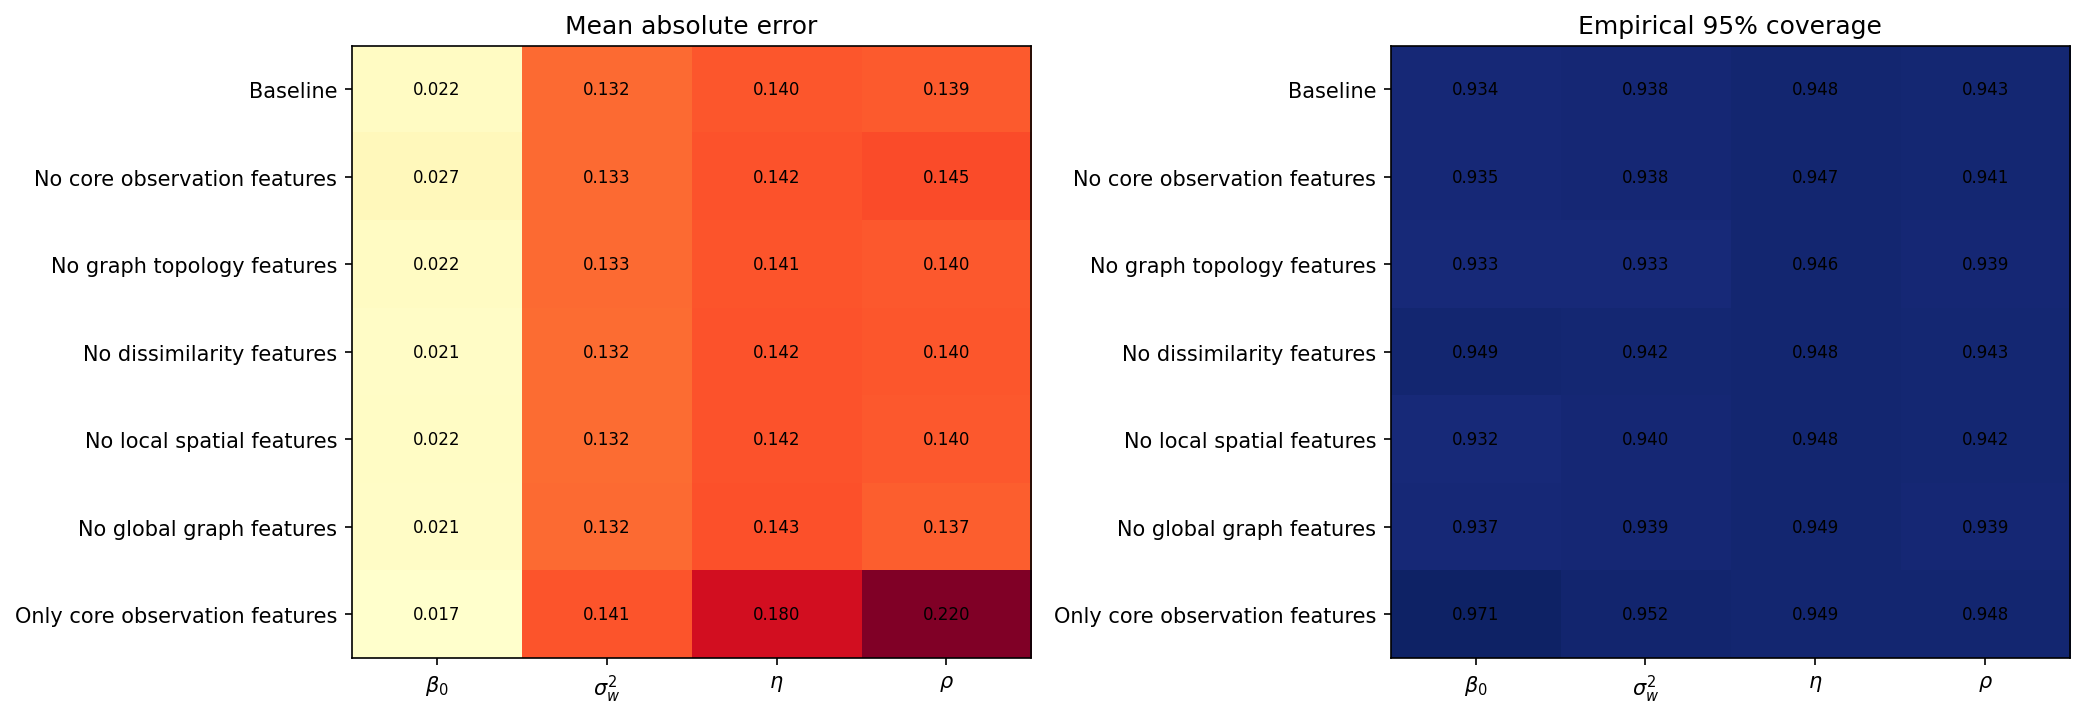

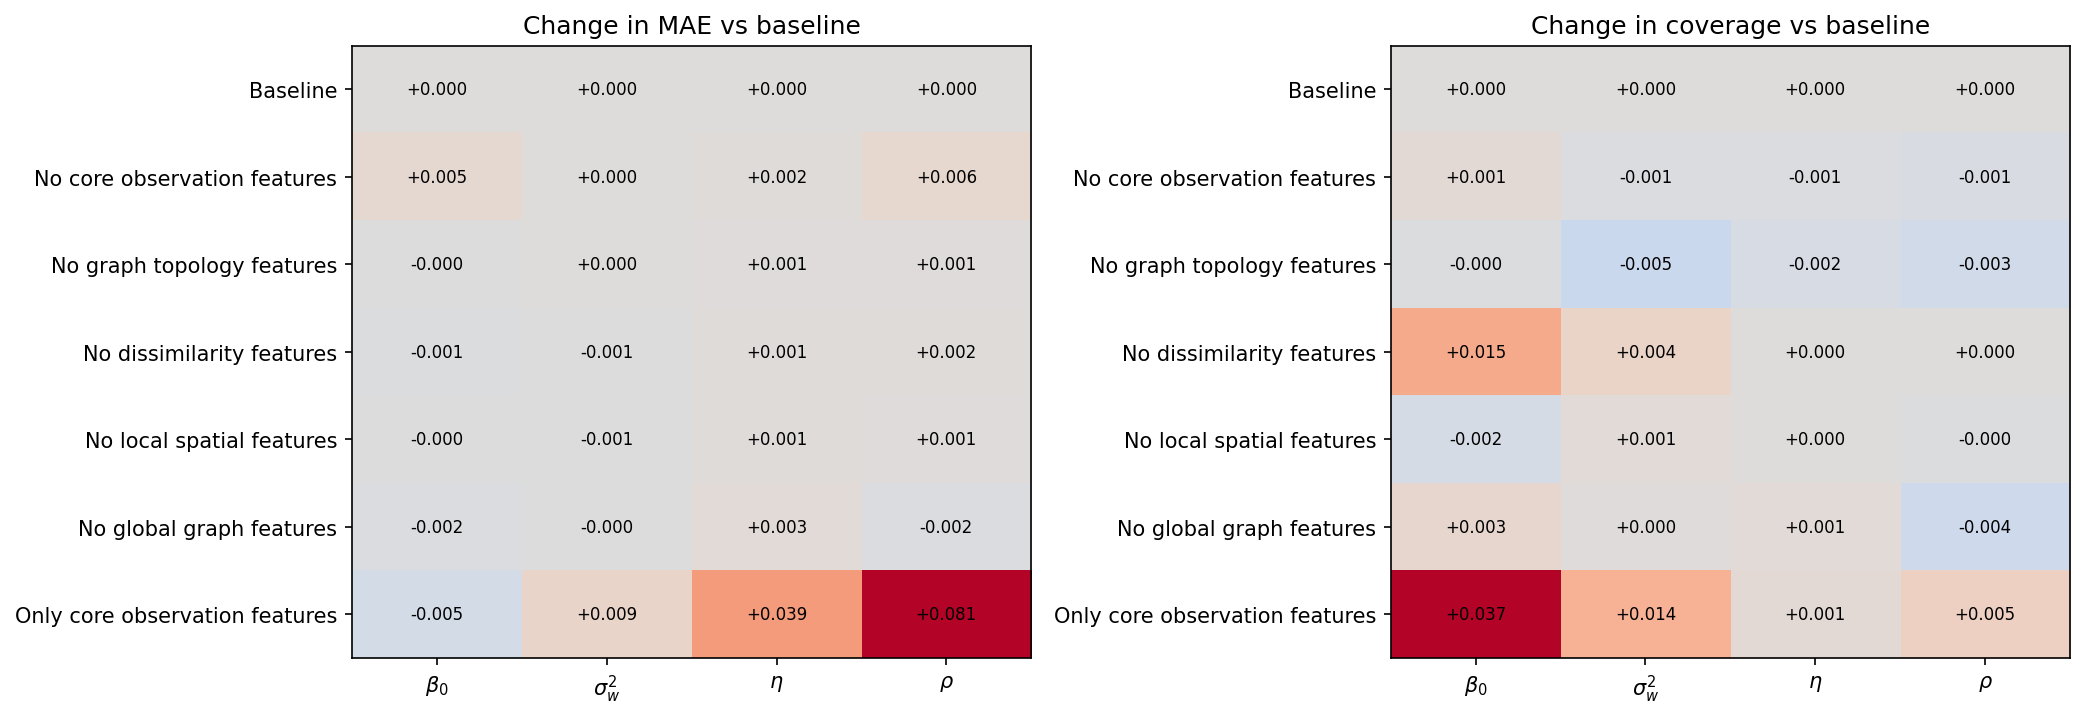

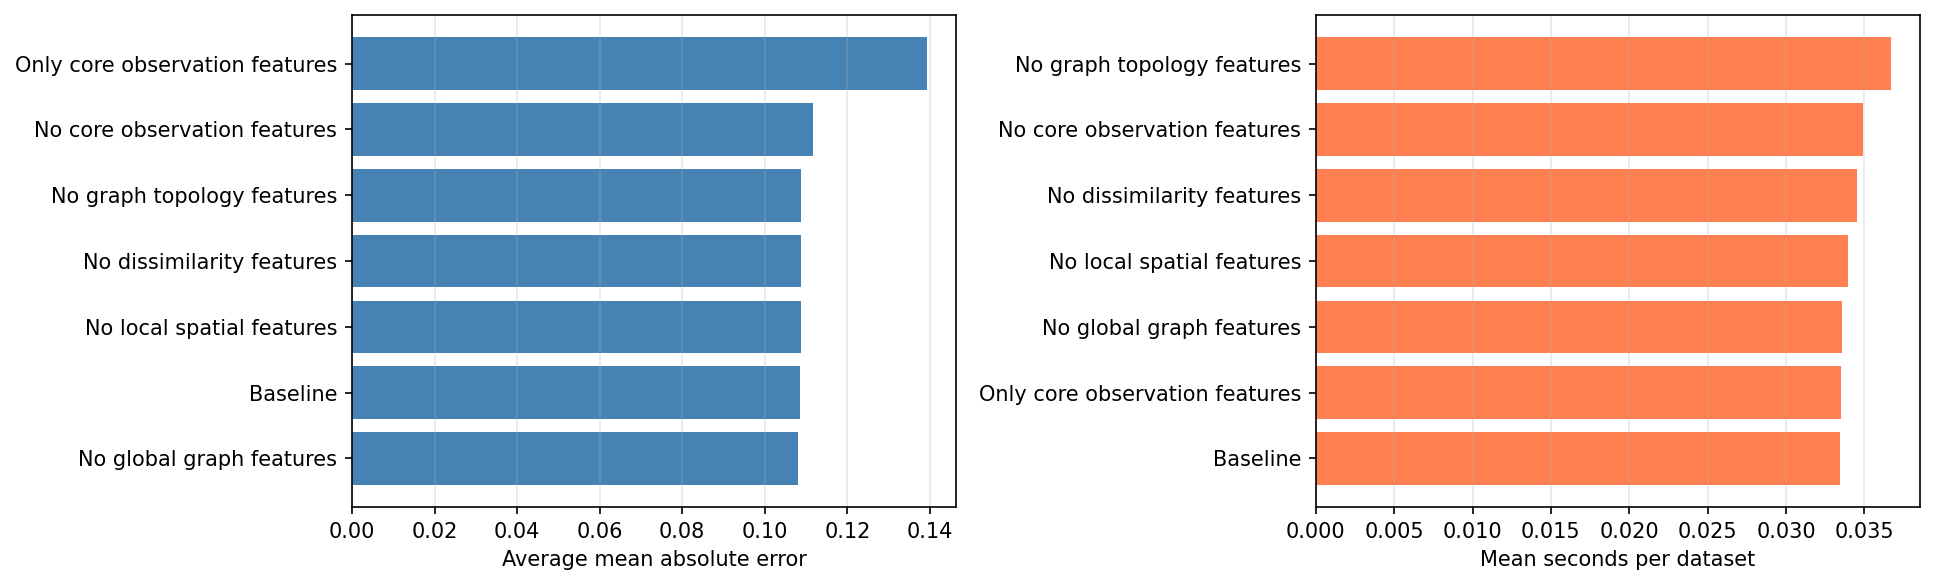

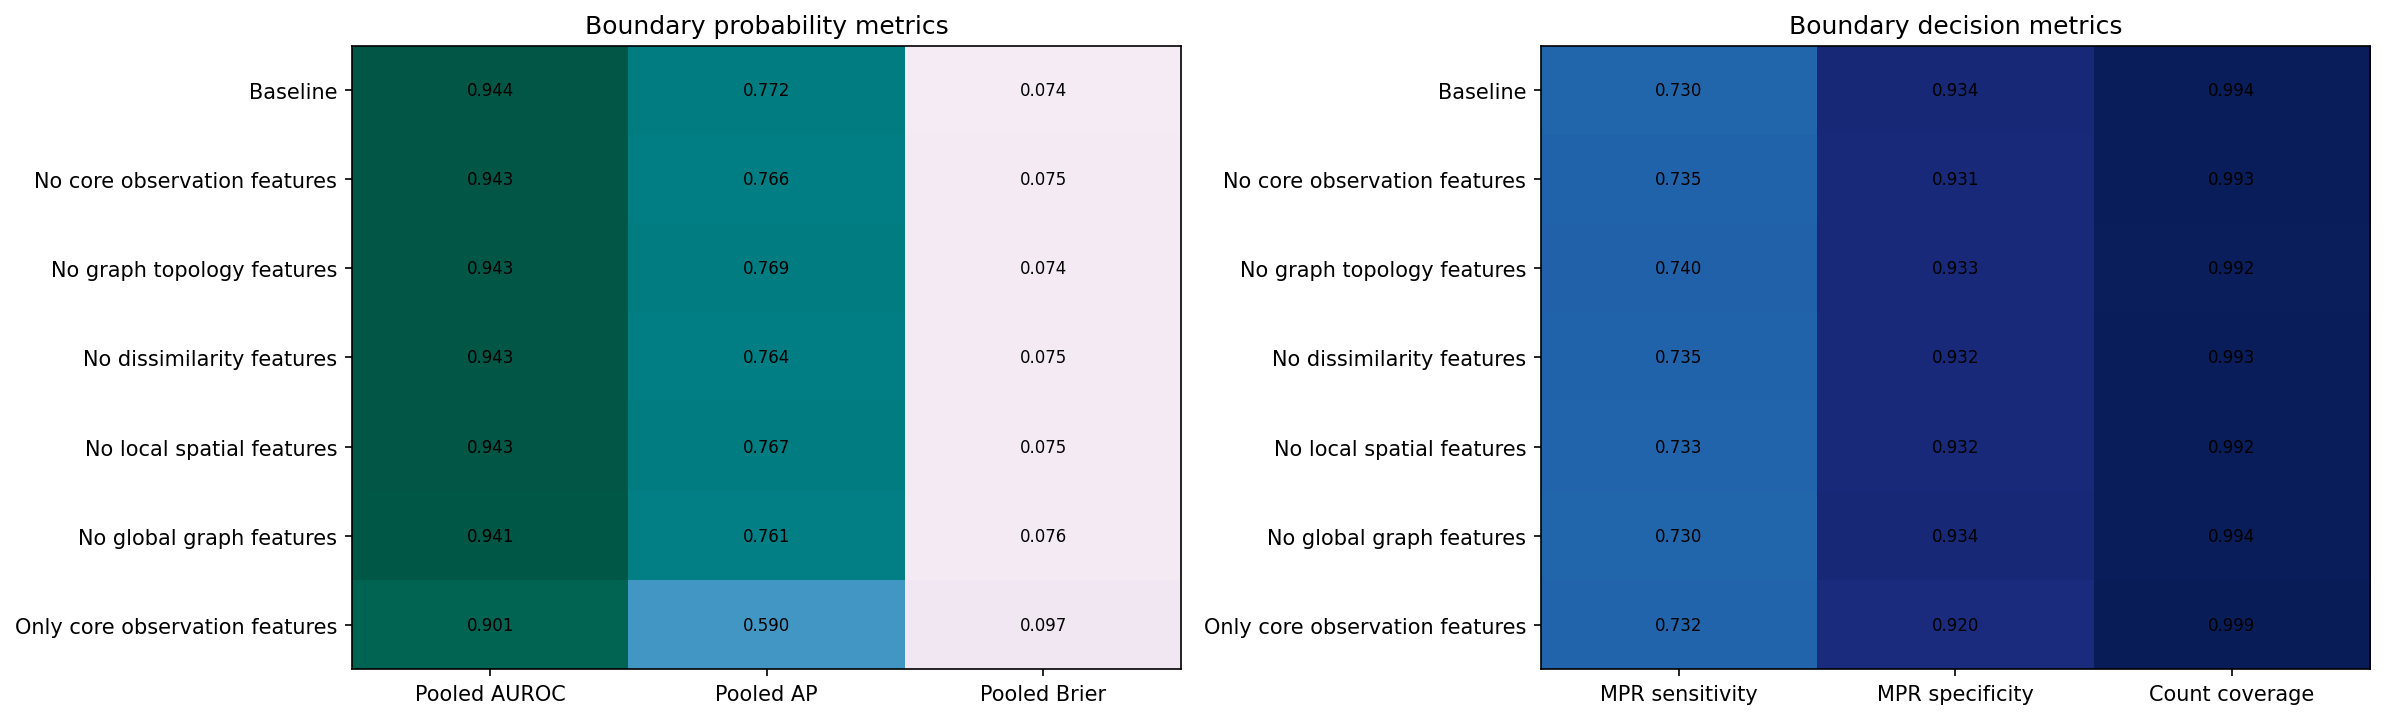

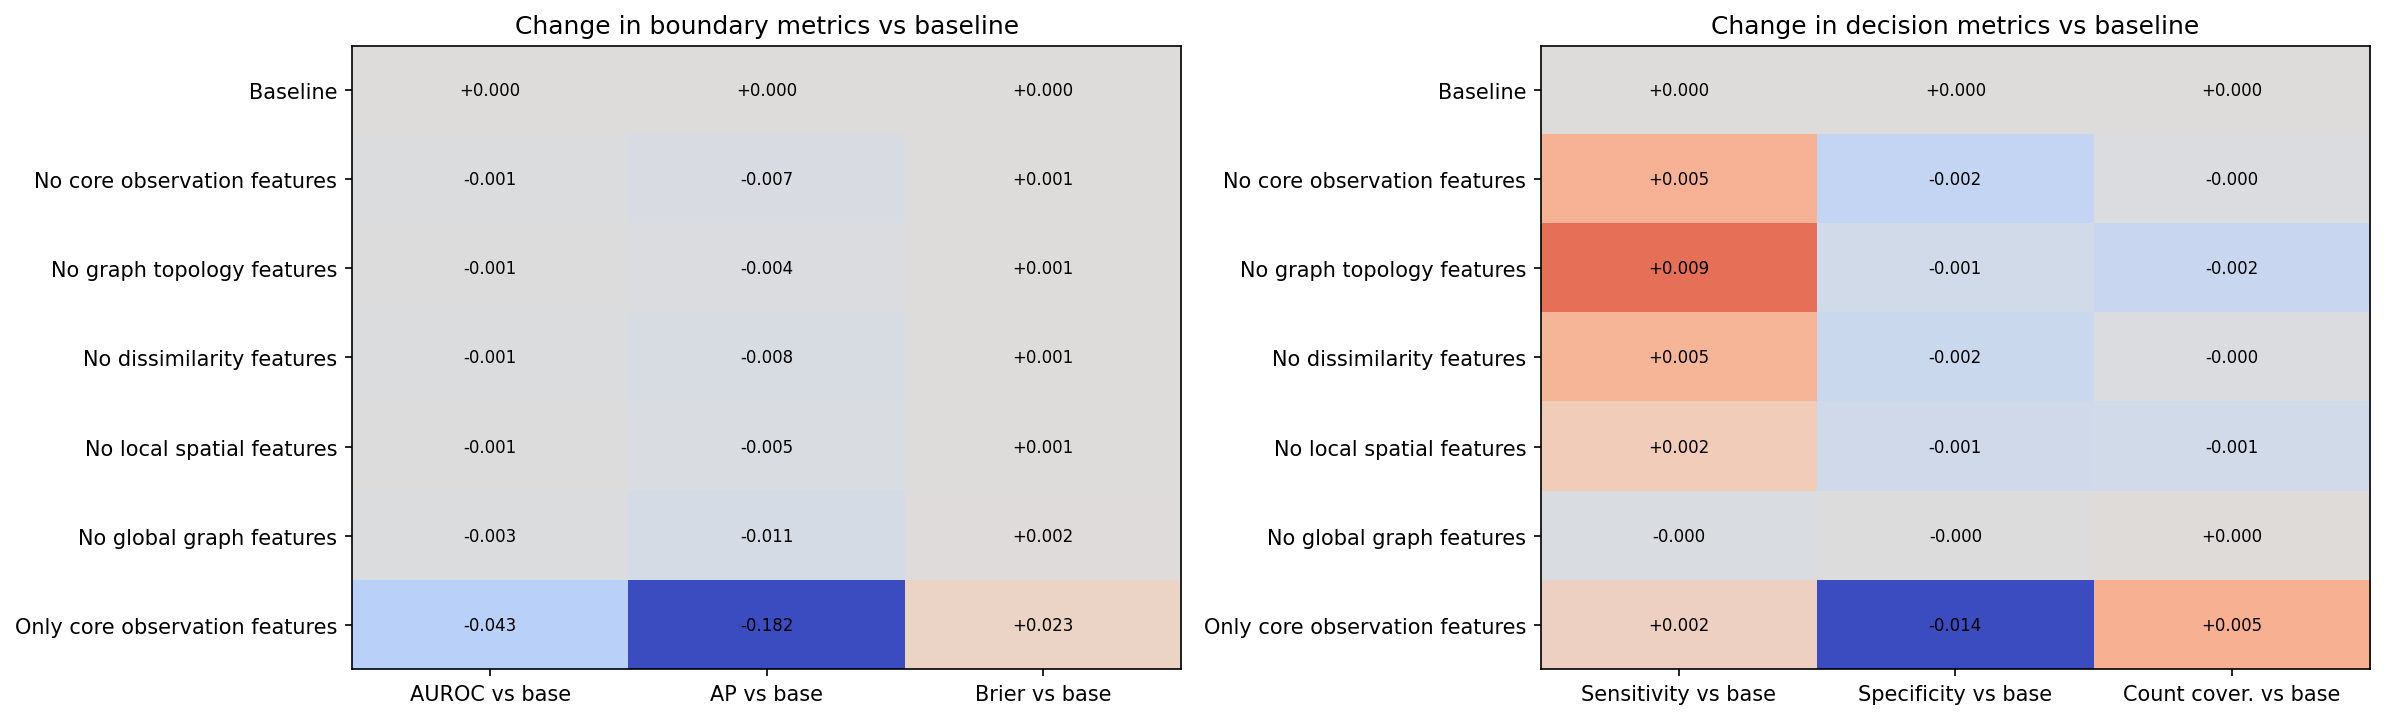

In [16]:
def _draw_annotated_heatmap(ax, data, cmap="viridis", fmt=".3f", vmin=None, vmax=None):
    values = data.to_numpy(dtype=float)
    im = ax.imshow(values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(list(data.columns))
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(list(data.index))
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            text = "NA" if np.isnan(val) else format(val, fmt)
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=8)
    return im

ordered_labels = [exp["label"] for exp in EXPERIMENTS if exp["label"] in set(summary_display_df["label"])]
parameter_label_map = globals().get(
    "PARAMETER_LABELS",
    {
        "beta0": r"$\beta_0$",
        "sigma2_w": r"$\sigma_w^2$",
        "eta": r"$\eta$",
        "rho": r"$\rho$",
    },
)
plot_parameter_labels = [parameter_label_map[param] for param in DISPLAY_PARAMETERS]
mae_pivot = summary_display_df.pivot(index="label", columns="parameter", values="mean_abs_error").reindex(index=ordered_labels, columns=DISPLAY_PARAMETERS)
coverage_pivot = summary_display_df.pivot(index="label", columns="parameter", values="mean_coverage_95").reindex(index=ordered_labels, columns=DISPLAY_PARAMETERS)
mae_pivot.columns = plot_parameter_labels
coverage_pivot.columns = plot_parameter_labels

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.7 * len(mae_pivot))))
_draw_annotated_heatmap(axes[0], mae_pivot, cmap="YlOrRd", fmt=".3f")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("Mean absolute error")
_draw_annotated_heatmap(axes[1], coverage_pivot, cmap="YlGnBu", fmt=".3f", vmin=0.0, vmax=1.0)
axes[1].axhline(-0.5, color="white", linewidth=0)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_title("Empirical 95% coverage")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "ablation_recovery_heatmaps.png", dpi=180, bbox_inches="tight")
plt.show()

if comparison_df["baseline_mean_abs_error"].notna().any():
    delta_mae_pivot = comparison_df.pivot(index="label", columns="parameter", values="delta_mean_abs_error_vs_baseline").reindex(index=ordered_labels, columns=DISPLAY_PARAMETERS)
    delta_cov_pivot = comparison_df.pivot(index="label", columns="parameter", values="delta_coverage_vs_baseline").reindex(index=ordered_labels, columns=DISPLAY_PARAMETERS)
    delta_mae_pivot.columns = plot_parameter_labels
    delta_cov_pivot.columns = plot_parameter_labels

    max_abs_mae = float(np.nanmax(np.abs(delta_mae_pivot.to_numpy(dtype=float)))) if delta_mae_pivot.notna().any().any() else 1.0
    max_abs_cov = float(np.nanmax(np.abs(delta_cov_pivot.to_numpy(dtype=float)))) if delta_cov_pivot.notna().any().any() else 1.0
    max_abs_mae = max(max_abs_mae, 1e-8)
    max_abs_cov = max(max_abs_cov, 1e-8)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.7 * len(delta_mae_pivot))))
    _draw_annotated_heatmap(axes[0], delta_mae_pivot, cmap="coolwarm", fmt="+.3f", vmin=-max_abs_mae, vmax=max_abs_mae)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].set_title("Change in MAE vs baseline")
    _draw_annotated_heatmap(axes[1], delta_cov_pivot, cmap="coolwarm", fmt="+.3f", vmin=-max_abs_cov, vmax=max_abs_cov)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    axes[1].set_title("Change in coverage vs baseline")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "ablation_delta_vs_baseline_heatmaps.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Baseline summary not available yet, so baseline-difference heatmaps were skipped.")

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, 0.55 * len(overall_df))))
ordered_overall = overall_df.sort_values("mean_abs_error_avg", ascending=True)
axes[0].barh(ordered_overall["label"], ordered_overall["mean_abs_error_avg"], color="steelblue")
axes[0].set_xlabel("Average mean absolute error")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.3)

runtime_plot_df = overall_df.sort_values("mean_seconds_per_dataset", ascending=True)
axes[1].barh(runtime_plot_df["label"], runtime_plot_df["mean_seconds_per_dataset"], color="coral")
axes[1].set_xlabel("Mean seconds per dataset")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "ablation_overall_summary.png", dpi=180, bbox_inches="tight")
plt.show()

if not boundary_summary_df.empty:
    boundary_metric_labels = {
        "pooled_auroc": "Pooled AUROC",
        "pooled_average_precision": "Pooled AP",
        "pooled_brier": "Pooled Brier",
        "mpm_mean_sensitivity": "MPR sensitivity",
        "mpm_mean_specificity": "MPR specificity",
        "boundary_count_coverage_95": "Count coverage",
    }
    boundary_plot_df = boundary_summary_df.set_index("label").reindex(ordered_labels)

    boundary_prob_metrics = ["pooled_auroc", "pooled_average_precision", "pooled_brier"]
    boundary_decision_metrics = ["mpm_mean_sensitivity", "mpm_mean_specificity", "boundary_count_coverage_95"]
    boundary_prob_pivot = boundary_plot_df[boundary_prob_metrics].copy()
    boundary_decision_pivot = boundary_plot_df[boundary_decision_metrics].copy()
    boundary_prob_pivot.columns = [boundary_metric_labels[col] for col in boundary_prob_metrics]
    boundary_decision_pivot.columns = [boundary_metric_labels[col] for col in boundary_decision_metrics]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 0.7 * len(boundary_plot_df))))
    _draw_annotated_heatmap(axes[0], boundary_prob_pivot, cmap="PuBuGn", fmt=".3f", vmin=0.0, vmax=1.0)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")
    axes[0].set_title("Boundary probability metrics")
    _draw_annotated_heatmap(axes[1], boundary_decision_pivot, cmap="YlGnBu", fmt=".3f", vmin=0.0, vmax=1.0)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
    axes[1].set_title("Boundary decision metrics")
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / "ablation_boundary_heatmaps.png", dpi=180, bbox_inches="tight")
    plt.show()

    if not boundary_comparison_df.empty:
        boundary_delta_df = boundary_comparison_df.set_index("label").reindex(ordered_labels)
        boundary_prob_delta_cols = [
            "delta_pooled_auroc_vs_baseline",
            "delta_pooled_average_precision_vs_baseline",
            "delta_pooled_brier_vs_baseline",
        ]
        boundary_decision_delta_cols = [
            "delta_mpm_mean_sensitivity_vs_baseline",
            "delta_mpm_mean_specificity_vs_baseline",
            "delta_boundary_count_coverage_95_vs_baseline",
        ]
        boundary_prob_delta = boundary_delta_df[boundary_prob_delta_cols].copy()
        boundary_decision_delta = boundary_delta_df[boundary_decision_delta_cols].copy()
        boundary_prob_delta.columns = [
            "AUROC vs base",
            "AP vs base",
            "Brier vs base",
        ]
        boundary_decision_delta.columns = [
            "Sensitivity vs base",
            "Specificity vs base",
            "Count cover. vs base",
        ]

        max_abs_prob = float(np.nanmax(np.abs(boundary_prob_delta.to_numpy(dtype=float)))) if boundary_prob_delta.notna().any().any() else 1.0
        max_abs_decision = float(np.nanmax(np.abs(boundary_decision_delta.to_numpy(dtype=float)))) if boundary_decision_delta.notna().any().any() else 1.0
        max_abs_prob = max(max_abs_prob, 1e-8)
        max_abs_decision = max(max_abs_decision, 1e-8)

        fig, axes = plt.subplots(1, 2, figsize=(16, max(4, 0.7 * len(boundary_delta_df))))
        _draw_annotated_heatmap(axes[0], boundary_prob_delta, cmap="coolwarm", fmt="+.3f", vmin=-max_abs_prob, vmax=max_abs_prob)
        axes[0].set_xlabel("")
        axes[0].set_ylabel("")
        axes[0].set_title("Change in boundary metrics vs baseline")
        _draw_annotated_heatmap(axes[1], boundary_decision_delta, cmap="coolwarm", fmt="+.3f", vmin=-max_abs_decision, vmax=max_abs_decision)
        axes[1].set_xlabel("")
        axes[1].set_ylabel("")
        axes[1].set_title("Change in decision metrics vs baseline")
        plt.tight_layout()
        plt.savefig(IMAGES_DIR / "ablation_boundary_delta_vs_baseline_heatmaps.png", dpi=180, bbox_inches="tight")
        plt.show()


In [11]:
output_manifest = pd.DataFrame(
    {
        "path": [str(path) for path in sorted(COMPARISON_OUTPUT_DIR.rglob("*")) if path.is_file()]
    }
)

display(output_manifest)
print("Saved comparison outputs to:")
print(COMPARISON_OUTPUT_DIR)


,path
0,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
1,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
2,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
3,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
4,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
5,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
6,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
7,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
8,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...
9,C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_p...


Saved comparison outputs to:
C:\Dati\Lavori\Aiello_Banerjee_2026\Code\ABI_poisson_regression\Simulation Experiments\Ablation_experiments\Results\comparison_outputs
